# Learn++ Implementation from Scratch

This notebook implements the Learn++ algorithm (Polikar et al., 2001) step by step.
Each section maps directly to the equations in `planning_seed/06_LEARNPP_ALGORITHM.md`.

## Why from scratch?
- Full understanding of internals for presentation and report
- Step-by-step comments explaining each decision
- Easy to modify for our specific comparison (MLP vs Decision Tree)

## Hardware
- Local: RTX A1000 + i9 (sufficient for this scale)

## Dependencies
```
numpy, scikit-learn, matplotlib, seaborn
```

In [ ]:
%pip install ipykernel scikit-learn matplotlib numpy seaborn

In [99]:
import numpy as np
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Learn++ Algorithm Overview

Learn++ is an **ensemble-based incremental learning** algorithm. It:
1. Receives data in sequential batches (D₁, D₂, D₃, ...)
2. Trains multiple weak hypotheses on each batch
3. Combines all hypotheses via weighted majority voting
4. Never discards old hypotheses — knowledge accumulates

### Key Idea
Each batch trains T_k base learners. Samples that are hard to classify get higher weights
(like AdaBoost), but across batches the ensemble only grows — it never forgets.

### Core Equations
| Symbol | Meaning |
|--------|---------|
| D_k | k-th data batch |
| T_k | Number of base learners trained on batch k |
| h_t | Base hypothesis (classifier) at iteration t |
| ε_t | Weighted error of h_t |
| β_t | Confidence weight = ε_t / (1 - ε_t) |
| w_i | Sample weight for instance i |
| H_final | Final ensemble (weighted majority vote) |

## 2. Base Learner Definitions

We compare two base learners within Learn++:

| Learner | Origin | Key Params | Why |
|---------|--------|-----------|-----|
| MLP (Multi-Layer Perceptron) | Original Learn++ paper (Polikar et al., 2001) | hidden_layers=(50,), max_iter=200 | The classifier used in the original paper for OCR |
| Decision Tree | Later Learn++ variants (Learn++.NSE, 2011) | max_depth=5 | Recommended for MRI/medical data; interpretable |

**Historical note**: The original Learn++ (2001) used MLP/SLP as base classifiers for optical character recognition. Decision Trees were adopted in later variants like Learn++.NSE (Elwell & Polikar, 2011). Gradient Boosting was never used in the original Learn++ papers (it is itself an ensemble of trees, creating a nested-ensemble if placed inside Learn++).

In [100]:
def make_paper_learner():
    """MLP (Multi-Layer Perceptron) — the original Learn++ base classifier.
    
    Why MLP?
    - This is the classifier from the original Learn++ paper (Polikar et al., 2001)
    - Used for OCR (optical character recognition) in the paper
    - Neural network with higher capacity than a single decision tree
    - Assignment requires using one algorithm from the paper
    - Question: does the original paper's classifier still outperform
      a tree-based model on our medical imaging task?
    """
    return MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,  # 500 iters to allow convergence (200 was too few)
        random_state=RANDOM_SEED
    )
def make_paper_learner_simple():
    """MLP (Multi-Layer Perceptron) — the original Learn++ base classifier.
    
    Why MLP?
    - This is the classifier from the original Learn++ paper (Polikar et al., 2001)
    - Used for OCR (optical character recognition) in the paper
    - Neural network with higher capacity than a single decision tree
    - Assignment requires using one algorithm from the paper
    - Question: does the original paper's classifier still outperform
      a tree-based model on our medical imaging task?
    """
    return MLPClassifier(
        hidden_layer_sizes=(10,),  # Smaller network for faster training on MNIST
        max_iter=100,  # Fewer iterations for quicker convergence on simpler data
        random_state=RANDOM_SEED
    )



def make_recommended_learner():
    """Decision Tree — base learner from later Learn++ variants (Learn++.NSE, 2011).
    
    Why Decision Tree?
    - Used in Learn++.NSE (Elwell & Polikar, 2011) as a proven base learner
    - Research shows strong performance on medical/MRI data
    - Interpretable: we can inspect what features drive splits
    - Fast to train, low memory footprint
    - Works well with ROI-based tabular features from BraTS
    """
    return DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_SEED
    )

## 3. Learn++ Implementation

### Step-by-step:
1. **Initialize** sample weights uniformly
2. **For each iteration t** in batch k:
   - Draw a weighted subset from the batch (using sample weights as distribution)
   - Train base learner h_t on the subset
   - Compute weighted error ε_t on the FULL batch
   - If ε_t ≥ 0.5: discard h_t, re-initialize weights, retry
   - Compute confidence: β_t = ε_t / (1 - ε_t)
   - Update sample weights: reduce weights of correctly classified samples
   - Normalize weights
3. **After all batches**: final prediction = weighted majority vote across all h_t

In [101]:
import numpy as np

class LearnPP:
    """Learn++ incremental learning algorithm.
    
    Reference: Polikar, R., Upda, L., Upda, S.S., & Honavar, V. (2001).
    Learn++: An incremental learning algorithm for supervised neural networks.
    """
    
    def __init__(self, base_learner_factory, T_k=10, max_retries=3):
        self.base_learner_factory = base_learner_factory
        self.T_k = T_k
        self.max_retries = max_retries
        
        self.hypotheses = []   
        self.betas = []        
        self.classes_ = None   
    
    def partial_fit(self, X, y):
        n_samples = len(X)
        
        # Track all known classes across batches
        if self.classes_ is None:
            self.classes_ = np.unique(y)
        else:
            self.classes_ = np.unique(np.concatenate([self.classes_, np.unique(y)]))
        
        # --- Eq. 1: Initialize sample weights uniformly ---
        w = np.ones(n_samples) / n_samples

        # init_dist
        if len(self.hypotheses) > 0:
            H_init = self.predict(X)
            E_init = np.sum(w[H_init != y])
            
            # FIX 1: Must clip at 0.499999 so B_init remains strictly < 1. 
            # Otherwise, correct instances get their weights INCREASED.
            E_init = np.clip(E_init, 1e-10, 0.499999)
            B_init = E_init / (1 - E_init)
            
            # Reduce weights of correctly classified instances
            correct_init = (H_init == y).astype(float)
            w = w * (B_init ** correct_init)
        
    
        for t in range(self.T_k):
            for retry in range(self.max_retries):
                # --- Eq. 2: Create training distribution D_t from weights ---
                sum_w = np.sum(w)
                if sum_w < 1e-15:
                    w = np.ones(n_samples) / n_samples
                    sum_w = 1.0
                D_t = w / sum_w

                indices = np.random.choice(
                    n_samples, size=n_samples, replace=True, p=D_t
                )
                X_train, y_train = X[indices], y[indices]
                
                # --- Eq. 3: Train base hypothesis h_t ---
                h_t = self.base_learner_factory()
                h_t.fit(X_train, y_train)
                
                # --- Eq. 4: Compute weighted error on FULL batch ---
                predictions = h_t.predict(X)
                incorrect = (predictions != y).astype(float)
                epsilon_t = np.dot(D_t, incorrect)  
                
                # --- Eq. 4: Check error condition ---
                if epsilon_t < 0.5:
                    break  # Good hypothesis, proceed
            else:
                continue # Retries failed
            
            # --- Eq. 6: Compute confidence weight ---
            beta_t = epsilon_t / (1 - epsilon_t + 1e-10)  # Small epsilon for stability
            
            self.hypotheses.append(h_t)
            self.betas.append(beta_t)
            
            # --- Step 6: Compute error of the composite hypothesis E_t ---
            H_t_predictions = self.predict(X)
            incorrect_H_t = (H_t_predictions != y).astype(float)
            e_t = np.dot(D_t, incorrect_H_t)
            
            # --- Eq. 7: Update sample weights opierając się na komitecie H_t ---
            e_t = np.clip(e_t, 1e-10, 0.499999)  # Clip to avoid division by zero and ensure b_t < 1
            b_t = e_t / (1 - e_t)  

            # Reduction of weights for correct instances
            correct_H_t = (H_t_predictions == y).astype(float)
            w = w * (b_t ** correct_H_t) 
            
        
    def predict(self, X):
        if not self.hypotheses:
            # Handle edge case where no hypotheses exist instead of crashing
            raise RuntimeError("No hypotheses trained yet. Call partial_fit first.")
        
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        
        votes = np.zeros((n_samples, n_classes))
        
        for h_t, beta_t in zip(self.hypotheses, self.betas):
            vote_weight = np.log(1.0 / (beta_t + 1e-10))
            predictions = h_t.predict(X)
            
            # OPTIMIZATION: Vectorized voting mapping. 
            # This replaces the slow 'for enumerate(predictions)' loop.
            for c_idx, c in enumerate(self.classes_):
                votes[predictions == c, c_idx] += vote_weight
                
        return self.classes_[np.argmax(votes, axis=1)]

## 4. Quick Validation on Synthetic Data

Before running on Fashion-MNIST or BraTS, let's verify the implementation works
on a simple 2D classification problem with incremental batches.

## 5. Next Steps

Once this validation passes:
1. **EXP-01**: Load Fashion-MNIST, design batches per `04_DATA_STRATEGY.md`, run comparison
2. **EXP-02**: Load BraTS, extract ROI features, run comparison
3. **Metrics**: Compute full CompositeScore (quality + cost)
4. **Statistics**: Wilcoxon signed-rank test for significance

See `planning_seed/03_EXPERIMENT_PLAN.md` for the full protocol.

In [106]:
#get data from ../data
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score

# 1. Wczytanie danych
print("Wczytywanie danych...")
train_set = pd.read_csv("../data/mnist_train.csv")
test_set = pd.read_csv("../data/mnist_test.csv")

print(f"Zbiór treningowy: {train_set.shape[0]} próbek, {train_set.shape[1]} cech (w tym etykieta)")
print(f"Zbiór testowy: {test_set.shape[0]} próbek, {test_set.shape[1]} cech (w tym etykieta)")

# Wyciągnięcie etykiet i cech dla zbioru TRENINGOWEGO
if 'label' in train_set.columns:
    y_train_full = train_set['label'].values
    X_train_full = train_set.drop('label', axis=1).values
else:
    y_train_full = train_set.iloc[:, 0].values
    X_train_full = train_set.iloc[:, 1:].values

# Wyciągnięcie etykiet i cech dla zbioru TESTOWEGO
if 'label' in test_set.columns:
    y_test = test_set['label'].values
    X_test = test_set.drop('label', axis=1).values
else:
    y_test = test_set.iloc[:, 0].values
    X_test = test_set.iloc[:, 1:].values

y_train_full = train_set['label'].values
X_train_full = train_set.drop('label', axis=1).values / 255.0  # Normalize to [0, 1]

# Wyciągnięcie etykiet i cech dla zbioru TESTOWEGO
# y_test = test_set['label'].values
# X_test = test_set.drop('label', axis=1).values / 255.0


Wczytywanie danych...
Zbiór treningowy: 60000 próbek, 785 cech (w tym etykieta)
Zbiór testowy: 10000 próbek, 785 cech (w tym etykieta)


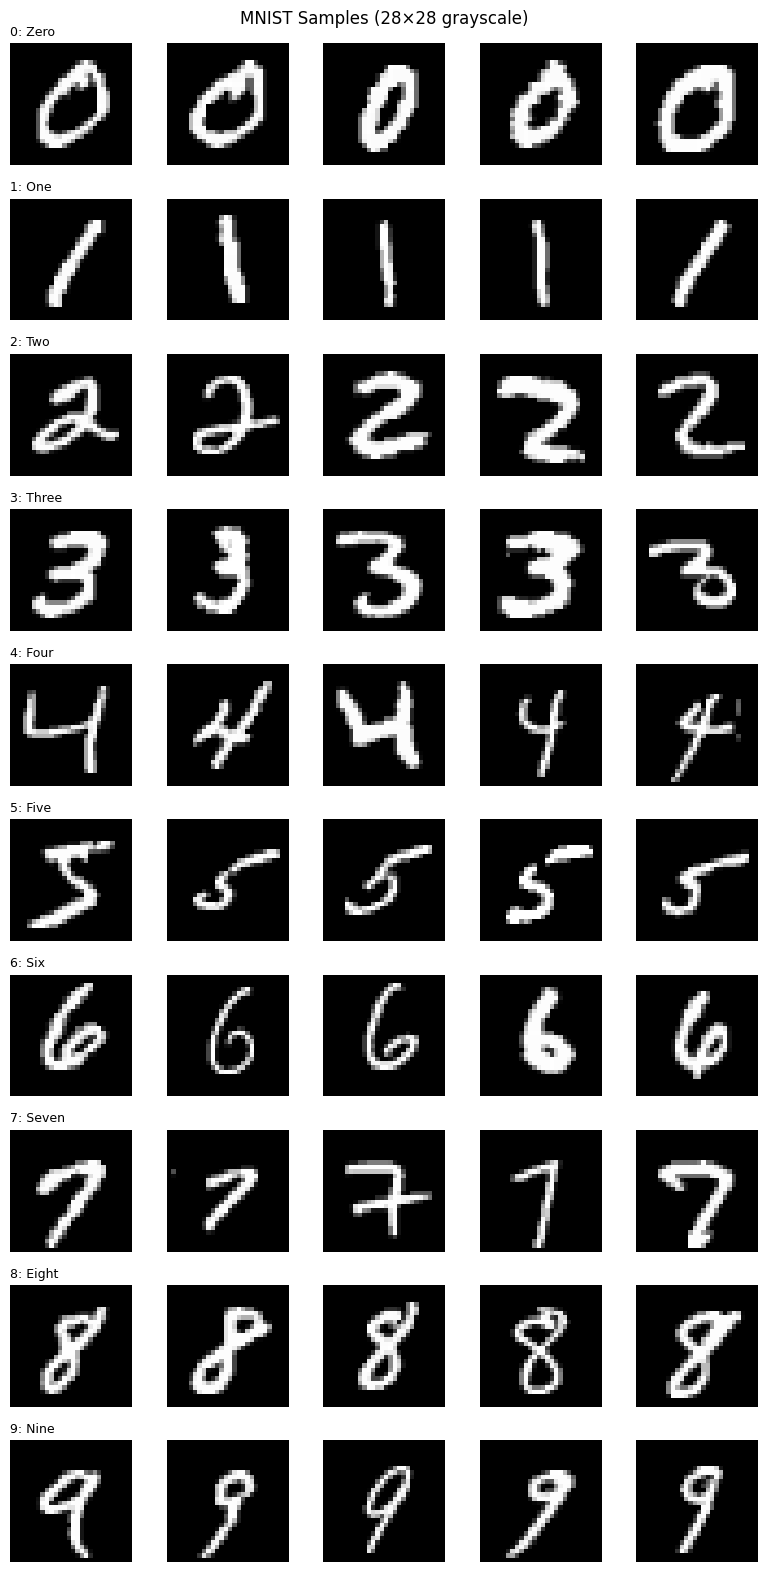


Saved to: digit_kaggle_mnist
Files:
  class_0_Zero.png
  class_1_One.png
  class_2_Two.png
  class_3_Three.png
  class_4_Four.png
  class_5_Five.png
  class_6_Six.png
  class_7_Seven.png
  class_8_Eight.png
  class_9_Nine.png
  mnist_grid.png


In [107]:
# --- Save sample Fashion-MNIST images as viewable PNGs ---
from pathlib import Path

class_names = ['Zero', 'One', 'Two', 'Three', 'Four', 
               'Five', 'Six', 'Seven', 'Eight', 'Nine']

out_dir = Path("digit_kaggle_mnist/")
out_dir.mkdir(parents=True, exist_ok=True)

# Save a grid: 5 examples per class (10 classes × 5 = 50 images in one figure)
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for class_idx in range(10):
    mask = y_train_full == class_idx
    samples = X_train_full[mask][:5]
    for col in range(5):
        ax = axes[class_idx, col]
        ax.imshow(samples[col].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f"{class_idx}: {class_names[class_idx]}", fontsize=9, loc='left')

plt.suptitle("MNIST Samples (28×28 grayscale)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir / "mnist_grid.png"), dpi=150, bbox_inches='tight')
plt.show()

# Also save individual PNGs for each class (first example)
for class_idx in range(10):
    mask = y_train_full == class_idx
    if np.any(mask):
        img = X_train_full[mask][0].reshape(28, 28)
        plt.imsave(str(out_dir / f"class_{class_idx}_{class_names[class_idx].replace('/', '_')}.png"), 
                   img, cmap='gray')

print(f"\nSaved to: {out_dir}")
print("Files:")
for f in sorted(out_dir.glob("*.png")):
    print(f"  {f.name}")

In [ ]:
# --- Revised PCA Dimensionality Reduction (Fixed Data Leakage) ---
from sklearn.decomposition import PCA

USE_PCA = True
N_COMPONENTS = 81

if USE_PCA:
    print(f"Applying PCA: {X_train_full.shape[0]} samples → {N_COMPONENTS} dimensions...")
    pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
    
    # Fit and transform ONLY on the training features (excluding labels)
    X_train_all = pca.fit_transform(X_train_full)
    explained = pca.explained_variance_ratio_.sum()
    print(f"  Training explained variance: {explained:.1%}")
    
    # Use .transform() on the test features so they use the training subspace map
    X_test_all = pca.transform(X_test)
    print(f"  New Train shape: {X_train_all.shape}, New Test shape: {X_test_all.shape}")
else:
    print("PCA disabled — using raw 784-dim pixels (slow for MLP)")
    X_train_all = X_train_full
    X_test_all = X_test

# Keep target labels synchronized
y_train_all = y_train_full
y_test_all = y_test

# --- Create incremental batches (simulate class introduction) ---
batch_classes = [
    [0,  2,  4,  6 ,8 ],
    [1, 3, 5, 9],
    [7]
]
dataset_name = "MNIST_Digits"

batches_dmnist = []
for classes in batch_classes:
    mask = np.isin(y_train_all, classes)
    batches_dmnist.append((X_train_all[mask], y_train_all[mask]))

print(f"\nBatch design ({dataset_name}):")
for i, (X_b, y_b) in enumerate(batches_dmnist, 1):
    classes_in = np.unique(y_b)
    print(f"  D{i}: {len(X_b)} samples, classes {classes_in}")
print(f"Test set: {len(X_test_all)} samples")



Batch design (MNIST_Digits):
  D1: 29492 samples, classes [0 2 4 6 8]
  D2: 24243 samples, classes [1 3 5 9]
  D3: 6265 samples, classes [7]
Test set: 10000 samples


In [109]:
import numpy as np

# --- REPLICATION OF TABLE 10 FROM THE ORIGINAL LEARN++ PUBLICATION ---
# Distribution specified in the paper (OCR Database): Class -> [S1, S2, S3, S4]
paper_distribution = {
    0: [100,  50,  50,  25],
    1: [  0, 150,  50,   0],
    2: [100,  50,  50,  25],
    3: [  0, 150,  50,  25],
    4: [100,  50,  50,   0],
    5: [  0, 150,  50,  25],
    6: [100,  50,   0, 100],
    7: [  0,   0, 150,  50],
    8: [100,   0,   0, 150],
    9: [  0,  50, 100,  50]
}

# Preparing 4 empty lists for data batches (D1, D2, D3, D4)
batches_X = [[], [], [], []]
batches_y = [[], [], [], []]

print("Overwriting 'batches_dmnist' variable with the original distribution from the paper...")

# Processing each class
for class_label, counts in paper_distribution.items():
    # Getting indices of all samples for a given class from the training set
    class_indices = np.where(y_train_all == class_label)[0]
    
    # Shuffling indices (to select different random samples each time)
    np.random.shuffle(class_indices)
    
    start_idx = 0
    # Distributing samples into subsequent batches
    for batch_idx, count in enumerate(counts):
        if count > 0:
            # Selecting exactly 'count' samples
            selected_indices = class_indices[start_idx : start_idx + count]
            batches_X[batch_idx].append(X_train_all[selected_indices])
            batches_y[batch_idx].append(y_train_all[selected_indices])
            start_idx += count

# Creating a new, overwritten list of batches
batches_dmnist = []
for i in range(4):
    X_batch = np.vstack(batches_X[i])
    y_batch = np.concatenate(batches_y[i])
    
    # Shuffling within the batch so classes are not ordered sequentially
    shuffle_idx = np.random.permutation(len(X_batch))
    batches_dmnist.append((X_batch[shuffle_idx], y_batch[shuffle_idx]))

# --- PRINTING RESULTS ---
print("\nFinal data distribution in batches (identical to Table 10):")
for i, (X_b, y_b) in enumerate(batches_dmnist, 1):
    classes_in_batch, counts_in_batch = np.unique(y_b, return_counts=True)
    
    # Formatting the display of classes and their counts
    dist_str = ", ".join([f"{cls}: {cnt}" for cls, cnt in zip(classes_in_batch, counts_in_batch)])
    print(f"  D{i}: {len(X_b)} samples, Class distribution: [{dist_str}]")

Overwriting 'batches_dmnist' variable with the original distribution from the paper...

Final data distribution in batches (identical to Table 10):
  D1: 500 samples, Class distribution: [0: 100, 2: 100, 4: 100, 6: 100, 8: 100]
  D2: 700 samples, Class distribution: [0: 50, 1: 150, 2: 50, 3: 150, 4: 50, 5: 150, 6: 50, 9: 50]
  D3: 550 samples, Class distribution: [0: 50, 1: 50, 2: 50, 3: 50, 4: 50, 5: 50, 7: 150, 9: 100]
  D4: 450 samples, Class distribution: [0: 25, 2: 25, 3: 25, 5: 25, 6: 100, 7: 50, 8: 150, 9: 50]


### 5.1 Run EXP-01: MLP (from paper) vs Decision Tree (recommended)

We run both classifiers through Learn++ on the same Fashion-MNIST batch sequence.
For each, we measure:
- **MacroF1** and **BalancedAccuracy** after each batch (quality)
- **Training time** per batch (cost)
- **Total ensemble size** (memory proxy)

In [110]:
def run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seed=42):
    """Run Learn++ with a given base learner and collect metrics per batch.
    
    Args:
        seed: Random seed for reproducibility. Affects numpy's global RNG
              (used in LearnPP sampling) and the base learner's random_state.
    Returns a dict with per-batch metrics for analysis.
    """
    np.random.seed(seed)
    model = LearnPP(base_learner_factory=learner_factory, T_k=T_k)
    
    results = {
        'learner': learner_name,
        'seed': seed,
        'batch_f1': [],
        'batch_ba': [],
        'batch_train_time': [],
        'batch_inference_time': [],
        'ensemble_sizes': [],
    }
    
    for k, (X_batch, y_batch) in enumerate(batches, 1):
        t_start = time.time()
        model.partial_fit(X_batch, y_batch)
        train_time = time.time() - t_start
        
        t_start = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - t_start
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        ba = balanced_accuracy_score(y_test, y_pred)
        
        results['batch_f1'].append(f1)
        results['batch_ba'].append(ba)
        results['batch_train_time'].append(train_time)
        results['batch_inference_time'].append(inference_time)
        results['ensemble_sizes'].append(len(model.hypotheses))
    
    results['total_train_time'] = sum(results['batch_train_time'])
    results['total_inference_time'] = sum(results['batch_inference_time'])
    results['final_f1'] = results['batch_f1'][-1]
    results['final_ba'] = results['batch_ba'][-1]
    
    return results


def run_multi_seed(learner_factory, learner_name, batches, X_test, y_test, 
                   T_k=10, seeds=None):
    """Run experiment across multiple seeds. Returns list of result dicts."""
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    
    all_results = []
    for s in seeds:
        r = run_experiment(learner_factory, learner_name, batches, X_test, y_test, 
                          T_k=T_k, seed=s)
        all_results.append(r)
    return all_results

In [111]:
from sklearn.metrics import accuracy_score

# Wymagane importy i inicjalizacja...
# Używaj clone() tak jak ustaliliśmy wcześniej!
from sklearn.base import clone

my_model = MLPClassifier(
    hidden_layer_sizes=(10,),  # Smaller network for faster training on MNIST
    max_iter=30,  # Fewer iterations for quicker convergence on simpler data
    random_state=RANDOM_SEED
)

ensemble = LearnPP(base_learner_factory=make_recommended_learner, T_k=10)

print("Starting Incremental Training...\n")

for i, (X_batch, y_batch) in enumerate(batches_dmnist):
    print(f"--- Processing Training Session {i+1} (TS{i+1}) ---")
    
    # 1. Trenowanie komitetu na nowej paczce
    ensemble.partial_fit(X_batch, y_batch)
    
    # 2. POPRAWKA: Ewaluacja na WSZYSTKICH dotychczasowych paczkach (S1, S2... S_i)
    print("Classification Performance (Train Acc):")
    for j in range(i + 1): 
        X_eval, y_eval = batches_dmnist[j]
        eval_preds = ensemble.predict(X_eval)
        eval_acc = accuracy_score(y_eval, eval_preds)
        print(f"  - Dataset S{j+1}: {eval_acc * 100:.2f}%")
    
    # 3. Ewaluacja generalizacji na globalnym zbiorze testowym
    test_preds = ensemble.predict(X_test_all)
    test_acc = accuracy_score(y_test_all, test_preds)
    
    print(f"Generalization Performance (Test Acc): {test_acc * 100:.2f}%\n")
    print(f"Training batch size = {len(X_batch)}, Ensemble size = {len(ensemble.hypotheses)}\n")

Starting Incremental Training...

--- Processing Training Session 1 (TS1) ---
Classification Performance (Train Acc):
  - Dataset S1: 94.80%
Generalization Performance (Test Acc): 37.70%

Training batch size = 500, Ensemble size = 10

--- Processing Training Session 2 (TS2) ---
Classification Performance (Train Acc):
  - Dataset S1: 94.00%
  - Dataset S2: 51.00%
Generalization Performance (Test Acc): 51.72%

Training batch size = 700, Ensemble size = 20

--- Processing Training Session 3 (TS3) ---
Classification Performance (Train Acc):
  - Dataset S1: 78.60%
  - Dataset S2: 76.86%
  - Dataset S3: 77.82%
Generalization Performance (Test Acc): 69.20%

Training batch size = 550, Ensemble size = 30

--- Processing Training Session 4 (TS4) ---
Classification Performance (Train Acc):
  - Dataset S1: 87.20%
  - Dataset S2: 75.14%
  - Dataset S3: 78.91%
  - Dataset S4: 84.44%
Generalization Performance (Test Acc): 75.67%

Training batch size = 450, Ensemble size = 40

